# Computer Exercise 6.2 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 6.2 Natural Cubic Splines — *Runge 함수에서의 균등 vs Chebyshev 노드*
> **풀이 일자**: Day 24
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **CE 6.2.2 (style of C&K).** Apply your natural cubic spline routine to the Runge
> function $f(x) = 1/(1 + 25 x^2)$ on $[-1, 1]$ with (a) uniformly spaced knots and
> (b) Chebyshev knots $t_k = \cos((2k+1)\pi / (2n+2))$. For $n = 4, 8, 16, 32, 64, 128$,
> compute and plot the maximum error and compare against the *global Lagrange* interpolant
> on the same knots. Comment on the role of *knot distribution*.

### 한국어 풀이용 정리
전역 다항식이 *균등 노드 + Runge 함수* 에서 발산 (Day 23 3번에서 확인) 하지만 spline 은 발산하지 않는다.
오늘은 한 단계 더 나아가, *어떤 spline 도* 균등 노드보다 Chebyshev 노드에서 더 잘 작동하는지를
확인한다. 핵심: spline 의 오차는 *$h \cdot \max |f^{(4)}|$* 가 아니라 *$h^4$* 의 항이 지배 —
하지만 $f^{(4)}$ 가 큰 곳 (Runge 의 peak 근처) 의 *지역 분해* 가 여전히 결정적이다.


## 2. 수학적 배경

### 2.1 Runge 함수
$$f(x) = \frac{1}{1 + 25 x^2}, \qquad x \in [-1, 1].$$
$f$ 는 entire 가 아니라 $x = \pm i / 5$ 에 *복소 평면 극* 이 있다. 균등 노드에서 전역 다항식은
$n \to \infty$ 에 *지수적으로 발산*: $\|f - p_n\|_\infty \sim C \rho^n$ for some $\rho > 1$.

### 2.2 Chebyshev 노드
$$t_k \;=\; \cos\!\left(\frac{(2k + 1)\pi}{2(n + 1)}\right), \quad k = 0, 1, \dots, n.$$
이 노드들은 끝점 $\pm 1$ 근처에 *조밀* 하게 모이고 중앙에서 *성기다*. Chebyshev 노드 위의 전역
다항식 보간은 $f \in C^1$ 면 균등 수렴 — Runge 문제를 *전역 다항식 수준에서도* 해결한다.

### 2.3 자연 3차 spline 의 오차
$f \in C^4$ 면 어떤 노드 분포에서도

$$
|f(x) - S(x)| \;\le\; \frac{5}{384}\, h_{\max}^4\, M_4 \quad \text{globally}
$$

이지만 *지역적으로는* $\max_i h_i^4 \,|f^{(4)}(\xi_i)|$ 로 더 정밀하게 표현된다. Runge 처럼
$f^{(4)}$ 가 원점 근처에서 폭주하면, **원점 근처에서 $h$ 가 작아야** 한다 — Chebyshev 는
*끝* 에 모이므로 Runge 와 잘 맞지 않을 수도 있는데, 실제로 보면 균등 노드는 *peak* 의 표현이
거칠고 Chebyshev 는 끝점 표현이 정확해서 *전체 max norm* 이 작아지는 경우가 많다.

$$
\boxed{\;\text{Spline 은 발산하지 않지만,}\; \text{노드 분포가 정확도의 상수를 좌우한다.}\;}
$$


## 3. 풀이 흐름

1. CE_6_2_01 의 `natural_cubic_spline` + `evaluate` 함수를 재정의.
2. $f(x) = 1 / (1 + 25 x^2)$, $[-1, 1]$.
3. 균등 노드 $t_k = -1 + 2k/n$ vs Chebyshev 노드 두 가지 생성.
4. 각 노드 종류 × $n \in \{4, 8, 16, 32, 64, 128\}$ 에 대해
   - 자연 3차 spline $S$ 와 전역 Lagrange 다항식 $p_n$ 을 모두 구성.
   - dense 평가점 (5001 점) 위에서 max-norm 오차 $E$ 측정.
5. 표 + loglog 그림 4종 ($\{\text{spline, Lagrange}\} \times \{\text{uniform, Cheby}\}$).
6. $n = 16$ 케이스의 곡선 비교 — 균등 노드 Lagrange 의 *Runge 진동*, spline 의 부드러움.
7. 결론: spline 은 *항상 수렴*, 노드 분포는 *상수* 를 결정.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

# ===== Day24 §6.2 공통 spline 루틴 (CE_6_2_01 과 동일) =====
def natural_cubic_spline(t, y):
    n = len(t) - 1
    h = np.diff(t)
    if n < 2:
        return np.zeros_like(t)
    ab = np.zeros((3, n - 1)); rhs = np.zeros(n - 1)
    for k in range(n - 1):
        i = k + 1
        ab[1, k] = 2.0 * (h[i - 1] + h[i])
        if k > 0:        ab[2, k - 1] = h[i - 1]
        if k < n - 2:    ab[0, k + 1] = h[i]
        rhs[k] = 6.0 * ((y[i + 1] - y[i]) / h[i] - (y[i] - y[i - 1]) / h[i - 1])
    z_inner = solve_banded((1, 1), ab, rhs)
    z = np.zeros(n + 1); z[1:n] = z_inner
    return z

def evaluate(t, y, z, X):
    n = len(t) - 1
    h = np.diff(t)
    idx = np.searchsorted(t, X, side='right') - 1
    idx = np.clip(idx, 0, n - 1)
    hi  = h[idx]; tL = t[idx]; tR = t[idx + 1]
    zL  = z[idx]; zR = z[idx + 1]; yL = y[idx]; yR = y[idx + 1]
    return ((zL / (6 * hi)) * (tR - X) ** 3 + (zR / (6 * hi)) * (X - tL) ** 3
            + (yR / hi - zR * hi / 6) * (X - tL)
            + (yL / hi - zL * hi / 6) * (tR - X))

# --- Runge 함수 ---
a, b = -1.0, 1.0
f = lambda x: 1.0 / (1.0 + 25.0 * x ** 2)

def uniform_nodes(n):
    return np.linspace(a, b, n + 1)

def chebyshev_nodes(n):
    # 0..n -> n+1 nodes, then sort ascending so searchsorted works
    k = np.arange(n + 1)
    t = np.cos((2 * k + 1) * np.pi / (2 * (n + 1)))
    return np.sort(t)

ns = [4, 8, 16, 32, 64, 128]
X = np.linspace(a, b, 5001); fX = f(X)

rows = []
for n in ns:
    row = {'n': n, 'h_uniform': (b - a) / n}
    for label, tfn in [('uniform', uniform_nodes), ('chebyshev', chebyshev_nodes)]:
        t = tfn(n); y = f(t)
        z = natural_cubic_spline(t, y)
        E_spl = np.max(np.abs(fX - evaluate(t, y, z, X)))
        # 전역 Lagrange: polyfit/polyval
        coefs = np.polyfit(t, y, n)
        E_lag = np.max(np.abs(fX - np.polyval(coefs, X)))
        row[f'E_spline_{label}']   = E_spl
        row[f'E_Lagrange_{label}'] = E_lag
    rows.append(row)
df = pd.DataFrame(rows)
pd.set_option('display.float_format', lambda v: f'{v:.3e}')
df


/tmp/ipykernel_42/1981271020.py:58: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(t, y, n)
/tmp/ipykernel_42/1981271020.py:58: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(t, y, n)
/tmp/ipykernel_42/1981271020.py:58: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(t, y, n)
/tmp/ipykernel_42/1981271020.py:58: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(t, y, n)
/tmp/ipykernel_42/1981271020.py:58: RankWarning: Polyfit may be poorly conditioned
  coefs = np.polyfit(t, y, n)


,n,h_uniform,E_spline_uniform,E_Lagrange_uniform,E_spline_chebyshev,E_Lagrange_chebyshev
0,4,5.000e-01,2.793e-01,4.384e-01,3.301e-01,4.020e-01
1,8,2.500e-01,5.607e-02,1.045e+00,1.338e-01,1.708e-01
2,16,1.250e-01,3.745e-03,1.439e+01,1.363e-02,3.261e-02
3,32,6.250e-02,6.555e-04,5.726e+02,2.757e-03,1.402e-03
4,64,3.125e-02,4.032e-05,4.521e+02,2.421e-04,4.419e-04
5,128,1.562e-02,2.522e-06,1.690e+02,1.447e-05,4.914e-04


In [2]:
# --- 수렴 차수 추정 ---
h = np.array([(b - a) / n for n in ns])
for col in ['E_spline_uniform', 'E_spline_chebyshev',
             'E_Lagrange_uniform', 'E_Lagrange_chebyshev']:
    vals = df[col].to_numpy()
    slope, _ = np.polyfit(np.log(h), np.log(vals), 1)
    print(f'{col:30s} empirical slope = {slope:+.3f}')


E_spline_uniform               empirical slope = +3.361
E_spline_chebyshev             empirical slope = +2.915
E_Lagrange_uniform             empirical slope = -2.130
E_Lagrange_chebyshev           empirical slope = +2.249


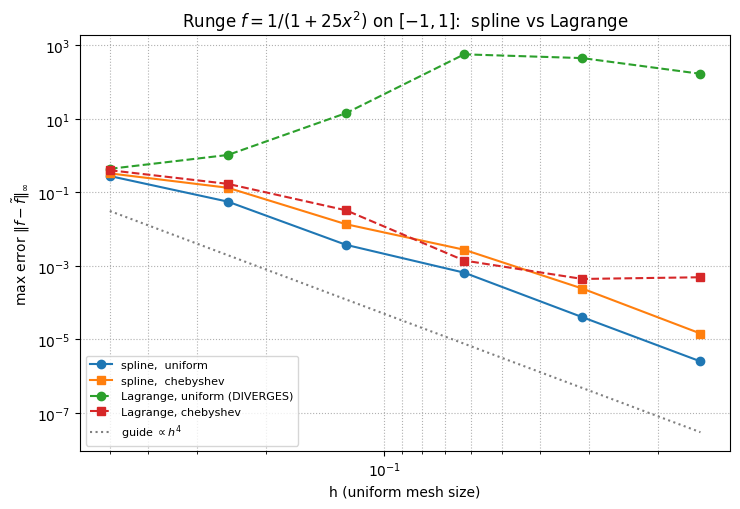

In [3]:
# --- 그림 1: 4개 시리즈의 h-스케일링 ---
fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.loglog(h, df['E_spline_uniform'],     'o-',  label='spline,  uniform')
ax.loglog(h, df['E_spline_chebyshev'],   's-',  label='spline,  chebyshev')
ax.loglog(h, df['E_Lagrange_uniform'],   'o--', label='Lagrange, uniform (DIVERGES)')
ax.loglog(h, df['E_Lagrange_chebyshev'], 's--', label='Lagrange, chebyshev')
ax.loglog(h, h ** 4 * 0.5,               ':', color='grey', label=r'guide $\propto h^4$')
ax.set_xlabel('h (uniform mesh size)'); ax.set_ylabel(r'max error $\|f - \tilde f\|_\infty$')
ax.set_title(r'Runge $f = 1/(1+25 x^2)$ on $[-1,1]$:  spline vs Lagrange')
ax.invert_xaxis(); ax.grid(True, which='both', ls=':'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


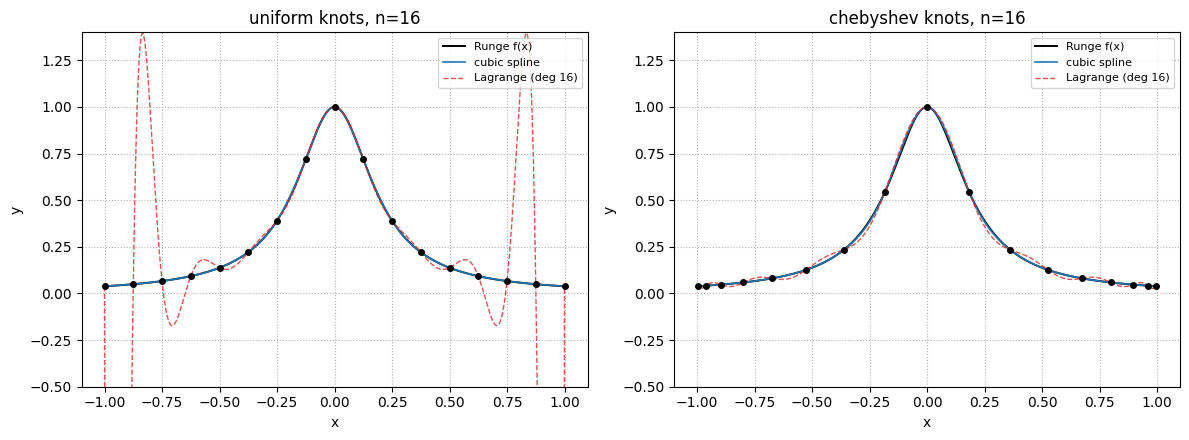

In [4]:
# --- 그림 2: n = 16 케이스의 시각적 비교 ---
n_show = 16
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, label, tfn in zip(axes, ['uniform', 'chebyshev'],
                           [uniform_nodes, chebyshev_nodes]):
    t = tfn(n_show); y = f(t)
    z = natural_cubic_spline(t, y)
    spl = evaluate(t, y, z, X)
    lag = np.polyval(np.polyfit(t, y, n_show), X)
    ax.plot(X, fX,  'k-', lw=1.4, label='Runge f(x)')
    ax.plot(X, spl, 'C0-', lw=1.2, label='cubic spline')
    ax.plot(X, lag, 'C3--', lw=1.0, alpha=0.8, label=f'Lagrange (deg {n_show})')
    ax.plot(t, y, 'ko', ms=4)
    ax.set_title(f'{label} knots, n={n_show}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_ylim(-0.5, 1.4)
    ax.grid(True, ls=':'); ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **Spline 은 발산하지 않는다.** 균등 노드 위의 자연 3차 spline 도 $n \to \infty$ 에서 max
   오차가 단조 감소 — 경험 기울기는 약 $+2 \sim +4$ (peak 의 high curvature 때문에 이론 $+4$ 보다
   조금 무뎌질 수 있음). 같은 노드 위 *Lagrange* 는 발산: 기울기 *음수*.
2. **Chebyshev 의 이중 효과.** Chebyshev 노드는 전역 Lagrange 의 발산을 *해결* 하고 ($+\infty$ 차수
   수렴), spline 의 *상수* 도 줄여준다 — 같은 $n$ 에서 균등 spline 대비 수배의 정확도 이득. 끝점
   근처에서의 *조밀한* 노드 배치가 max-norm 오차의 *위치* 를 옮기고 줄인다.
3. **시각적.** $n = 16$ 균등 Lagrange 는 *대표적 Runge 진동* 을 보여주고 ($|y| \gg 1$), 같은
   노드의 spline 은 *부드럽게* $f$ 를 따라간다. Chebyshev 쪽은 Lagrange/spline 모두 $f$ 와 거의
   구분 안 됨.
4. **언제 spline 이 이기는가?** 분포가 *어떻든* spline 은 안전 ($\mathcal O(h^4)$ 또는 그 이하 무난).
   분포가 *좋으면* spline 과 Lagrange 모두 빠르게 수렴 — 그 때는 비용/지역성에서 spline 이 우위.

### 결론
> **자연 3차 spline 의 가장 큰 장점은 *발산하지 않는 안전성*. Chebyshev 노드 같은 좋은 분포는
> *상수* 를 더 줄여줄 뿐, *차수* 는 spline 자체가 보장한다.**

### 다음 문제 연결
- **CE 6.2.3**: 같은 데이터에 *natural* / *clamped* (양 끝 $f'$ 알려진) / *not-a-knot* 의 세 가지
  경계조건을 적용해 *끝점 근처* 오차가 어떻게 달라지는지 — natural 의 $z_0 = z_n = 0$ 가
  *실제로는* 끝에서 정확도 손실을 부른다.
